In [3]:
import pandas as pd

drop_columns = ["Unnamed: 15"]
columns = ["Team", "League", "home_winrate", "away_winrate"]
winrate_df = (
    pd
    .read_csv("./soccer.csv")
    .drop(drop_columns, axis=1)
    .assign(
        home_winrate=lambda df: df.HomeWins / (df.HomeWins + df.HomeDraw + df.HomeLoss),
        away_winrate=lambda df: df.AwayWins / (df.AwayWins + df.AwayDraw + df.AwayLoss)
    )
    .loc[:, columns]
)

In [42]:
ru_winrate_df = winrate_df[winrate_df.League == "Russia-Premier-Liga"]

In [53]:
print(ru_winrate_df.home_winrate.mean())
print(ru_winrate_df.away_winrate.mean())
print(ru_winrate_df.home_winrate.var(ddof=1))
print(ru_winrate_df.away_winrate.var(ddof=1))

0.4431697931697931
0.28776905964405963
0.028489229356541218
0.027166361091018092


In [64]:
from scipy.stats import t

print(t.ppf(0.975, 191))
print(t.ppf(0.95, 191))

1.972461989767211
1.6528705472303888


In [67]:
from scipy.stats import f
print(ru_winrate_df.home_winrate.var(ddof=1) / ru_winrate_df.away_winrate.var(ddof=1))
print(f.ppf(0.95, 191, 191))

1.0486950851124666
1.269506759238109


In [85]:
(
    pd.concat((
        ru_winrate_df.home_winrate.to_frame().assign(where="home").rename({"home_winrate" : "winrate"}, axis=1), 
        ru_winrate_df.away_winrate.to_frame().assign(where="away").rename({"away_winrate" : "winrate"}, axis=1)
    ), axis=0)
    .sort_values("winrate")
    .reset_index(drop=True)
    .reset_index(names=["rank"])
    .query("where == 'away'")
    .loc[:, ["rank"]]
    .sum()
)

rank    27944
dtype: int64

In [ ]:
home = ru_winrate_df.home_winrate - ru_winrate_df.home_winrate.median()
away = ru_winrate_df.away_winrate - ru_winrate_df.away_winrate.median()

long = pd.concat([home.to_frame('winrate').assign(where='home'),
                  away.to_frame('winrate').assign(where='away')])

n = len(long)
a = (long.sort_values('winrate').reset_index(drop=True).reset_index(names='pos')
      .assign(rank=lambda x: x['pos'].apply(lambda p: min(p+1, n-p)))
      .query("where=='away'")['rank'].sum())
print(a)

18847


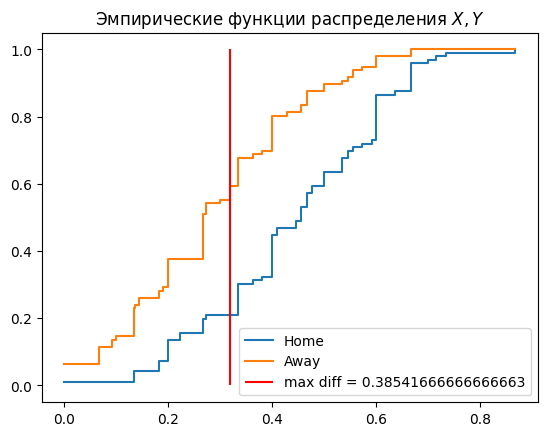

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

x = ru_winrate_df.home_winrate
y = ru_winrate_df.away_winrate

ecdf_x = ECDF(x)
ecdf_y = ECDF(y)

grid = np.sort(np.concatenate([x, y]))
diff = np.abs(ecdf_x(grid) - ecdf_y(grid))
ks_stat = np.max(diff)
max_idx = np.argmax(diff)

plt.step(grid, ecdf_x(grid), where='post', label='Home')
plt.step(grid, ecdf_y(grid), where='post', label='Away')
plt.vlines(grid[max_idx], 0, 1, colors='red', label=f'max diff = {ks_stat}')
plt.title("Эмпирические функции распределения $X, Y$")
plt.legend()
plt.savefig("./img/empirical.png")
plt.show()

In [95]:
from scipy.stats import kstwobign

quantile_asymp = kstwobign.ppf(0.95) 
print(quantile_asymp)

1.3580986393225505
